# Hyperparameter Tuning - Kathmandu AQI Project

## 1. Load data, prepare delta target

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/kathmandu_features.csv")
df["datetime_utc"] = pd.to_datetime(df["datetime_utc"])
df = df.sort_values("datetime_utc").reset_index(drop=True)

target_column = "target_pm25_next_1h"
feature_columns = [col for col in df.columns if col not in ["datetime_utc", target_column]]

current_pm25 = df["pm25"]
y_absolute = df[target_column]
y_delta = y_absolute - current_pm25

# Drop rows where the delta target is NaN -- required before tuning, same as
# in every earlier delta-target notebook (can't train on a missing target).
# This only removes specific time points; it does not reorder or shuffle
# anything, so chronological order is preserved for TimeSeriesSplit.
valid_mask = ~y_delta.isna()
X = df.loc[valid_mask, feature_columns].reset_index(drop=True)
y_delta_valid = y_delta[valid_mask].reset_index(drop=True)
y_absolute_valid = y_absolute[valid_mask].reset_index(drop=True)
current_pm25_valid = current_pm25[valid_mask].reset_index(drop=True)
dates_valid = df.loc[valid_mask, "datetime_utc"].reset_index(drop=True)

print(f"Rows after dropping missing target: {len(X)} (from {len(df)})")
print(f"Features: {len(feature_columns)}")

Rows after dropping missing target: 8312 (from 8343)
Features: 32


## 2. Define the search space and run RandomizedSearchCV


In [2]:
param_distributions = {
    "n_estimators": [50, 100, 150, 200, 300],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 1.5, 2],
}

tscv = TimeSeriesSplit(n_splits=5)

base_model = xgb.XGBRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X, y_delta_valid)

print("Best parameters found:")
print(search.best_params_)
print(f"\nBest CV RMSE (on delta target): {-search.best_score_:.3f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found:
{'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

Best CV RMSE (on delta target): 12.889


## 3. Evaluate the tuned model on the same folds, reconstructed to absolute PM2.5


In [3]:
tuned_results = []
tuned_predictions = []

best_params = search.best_params_

for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_delta_train = y_delta_valid.iloc[train_idx]
    y_absolute_test = y_absolute_valid.iloc[test_idx]
    current_pm25_test = current_pm25_valid.iloc[test_idx]
    dates_test = dates_valid.iloc[test_idx]

    model = xgb.XGBRegressor(random_state=42, n_jobs=-1, **best_params)
    model.fit(X_train, y_delta_train)

    predicted_delta = model.predict(X_test)
    predicted_absolute = current_pm25_test.values + predicted_delta

    valid_mask_fold = ~np.isnan(predicted_absolute)

    rmse = np.sqrt(mean_squared_error(y_absolute_test[valid_mask_fold], predicted_absolute[valid_mask_fold]))
    mae = mean_absolute_error(y_absolute_test[valid_mask_fold], predicted_absolute[valid_mask_fold])
    r2 = r2_score(y_absolute_test[valid_mask_fold], predicted_absolute[valid_mask_fold])

    tuned_results.append({"fold": fold_num, "rmse_tuned": rmse, "mae_tuned": mae, "r2_tuned": r2})
    tuned_predictions.append({
        "fold": fold_num, "dates": dates_test[valid_mask_fold],
        "y_actual": y_absolute_test[valid_mask_fold], "y_pred": predicted_absolute[valid_mask_fold],
    })

    print(f"Fold {fold_num} ({dates_test.min().date()} to {dates_test.max().date()}): "
          f"RMSE={rmse:.2f} MAE={mae:.2f} R2={r2:.3f}")

tuned_df = pd.DataFrame(tuned_results)

Fold 1 (2025-12-24 to 2026-01-30): RMSE=20.68 MAE=13.74 R2=0.757
Fold 2 (2026-01-30 to 2026-04-04): RMSE=15.82 MAE=9.68 R2=0.810
Fold 3 (2026-04-04 to 2026-06-06): RMSE=13.83 MAE=8.59 R2=0.907
Fold 4 (2026-06-06 to 2026-07-30): RMSE=7.49 MAE=4.67 R2=0.793
Fold 5 (2026-07-30 to 2026-09-03): RMSE=6.55 MAE=4.27 R2=0.635


## 4. Compare tuned model against the untuned XGBoost and persistence

In [5]:
# Persistence, recomputed on the same valid-row set
persist_results = []
for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    y_absolute_test = y_absolute_valid.iloc[test_idx]
    current_pm25_test = current_pm25_valid.iloc[test_idx]
    valid_mask_p = ~current_pm25_test.isna()
    rmse_p = np.sqrt(mean_squared_error(y_absolute_test[valid_mask_p], current_pm25_test[valid_mask_p]))
    r2_p = r2_score(y_absolute_test[valid_mask_p], current_pm25_test[valid_mask_p])
    persist_results.append({"fold": fold_num, "rmse_persist": rmse_p, "r2_persist": r2_p})
persist_df = pd.DataFrame(persist_results)

# Untuned XGBoost (previous best: n_estimators=300, max_depth=5), for comparison
untuned_results = []
for fold_num, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_delta_train = y_delta_valid.iloc[train_idx]
    y_absolute_test = y_absolute_valid.iloc[test_idx]
    current_pm25_test = current_pm25_valid.iloc[test_idx]

    untuned_model = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1)
    untuned_model.fit(X_train, y_delta_train)
    pred_delta = untuned_model.predict(X_test)
    pred_absolute = current_pm25_test.values + pred_delta

    valid_mask_u = ~np.isnan(pred_absolute)
    rmse_u = np.sqrt(mean_squared_error(y_absolute_test[valid_mask_u], pred_absolute[valid_mask_u]))
    r2_u = r2_score(y_absolute_test[valid_mask_u], pred_absolute[valid_mask_u])
    untuned_results.append({"fold": fold_num, "rmse_untuned": rmse_u, "r2_untuned": r2_u})
untuned_df = pd.DataFrame(untuned_results)

final_comparison = tuned_df.merge(untuned_df, on="fold").merge(persist_df, on="fold")

print(final_comparison[["fold", "rmse_tuned", "rmse_untuned", "rmse_persist"]].to_string(index=False))
print()
print(final_comparison[["fold", "r2_tuned", "r2_untuned", "r2_persist"]].to_string(index=False))

print()
print("=== AVERAGES ===")
print(f"Tuned XGBoost   : RMSE={final_comparison['rmse_tuned'].mean():.2f}  R2={final_comparison['r2_tuned'].mean():.3f}")
print(f"Untuned XGBoost : RMSE={final_comparison['rmse_untuned'].mean():.2f}  R2={final_comparison['r2_untuned'].mean():.3f}")
print(f"Persistence     : RMSE={final_comparison['rmse_persist'].mean():.2f}  R2={final_comparison['r2_persist'].mean():.3f}")

improvement_vs_persist = (1 - final_comparison['rmse_tuned'].mean() / final_comparison['rmse_persist'].mean()) * 100
improvement_vs_untuned = (1 - final_comparison['rmse_tuned'].mean() / final_comparison['rmse_untuned'].mean()) * 100
print(f"\nTuned model improvement over persistence: {improvement_vs_persist:.1f}%")
print(f"Tuned model improvement over untuned XGBoost: {improvement_vs_untuned:.1f}%")

 fold  rmse_tuned  rmse_untuned  rmse_persist
    1   20.680787     21.634391     25.864550
    2   15.818751     20.236150     18.838286
    3   13.833925     20.999686     13.131767
    4    7.488840      7.467273      7.739128
    5    6.551148      6.881309      7.025616

 fold  r2_tuned  r2_untuned  r2_persist
    1  0.756589    0.733624    0.619271
    2  0.810008    0.689081    0.730553
    3  0.906804    0.785251    0.916025
    4  0.793288    0.794477    0.779240
    5  0.634722    0.596976    0.579895

=== AVERAGES ===
Tuned XGBoost   : RMSE=12.87  R2=0.780
Untuned XGBoost : RMSE=15.44  R2=0.720
Persistence     : RMSE=14.52  R2=0.725

Tuned model improvement over persistence: 11.3%
Tuned model improvement over untuned XGBoost: 16.6%


## 5. RMSE per fold — all three

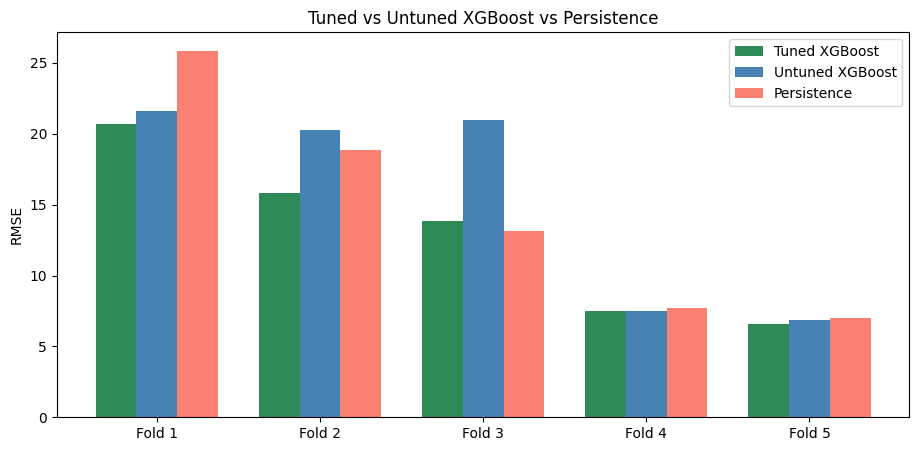

In [6]:
x = np.arange(5)
width = 0.25

plt.figure(figsize=(11, 5))
plt.bar(x - width, final_comparison["rmse_tuned"], width, label="Tuned XGBoost", color="seagreen")
plt.bar(x, final_comparison["rmse_untuned"], width, label="Untuned XGBoost", color="steelblue")
plt.bar(x + width, final_comparison["rmse_persist"], width, label="Persistence", color="salmon")
plt.xticks(x, [f"Fold {i+1}" for i in range(5)])
plt.ylabel("RMSE")
plt.title("Tuned vs Untuned XGBoost vs Persistence")
plt.legend()
plt.show()

## 6. Predicted vs actual, per fold (tuned model)

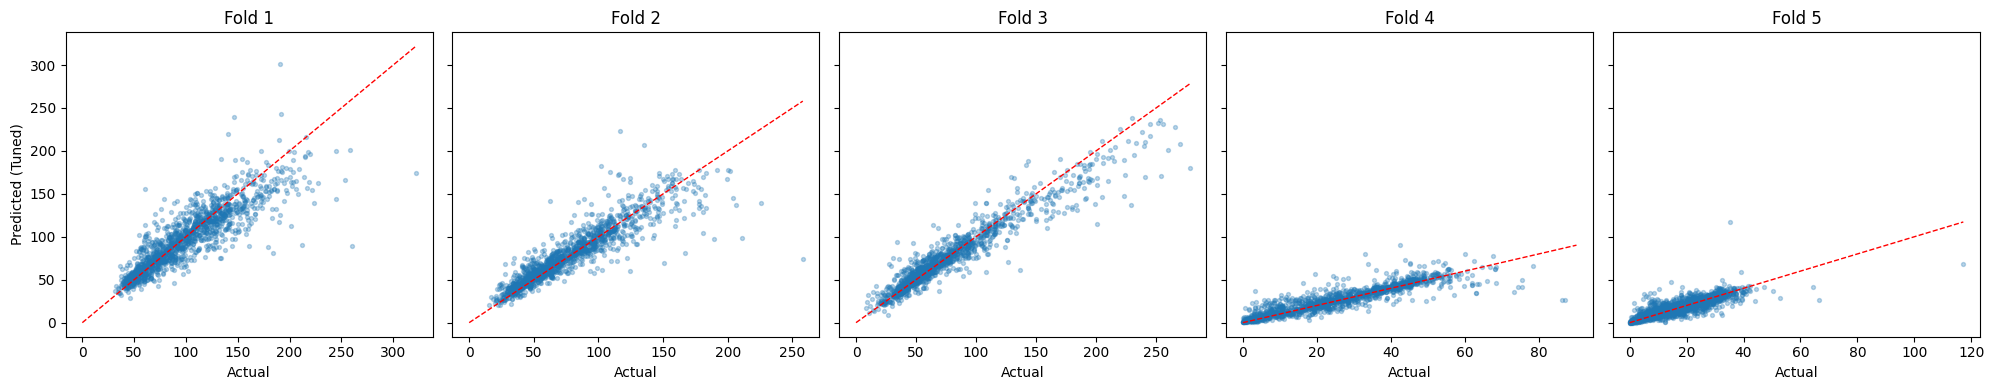

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)

for i, fold_data in enumerate(tuned_predictions):
    ax = axes[i]
    ax.scatter(fold_data["y_actual"], fold_data["y_pred"], alpha=0.3, s=8)
    lims = [0, max(fold_data["y_actual"].max(), fold_data["y_pred"].max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(f"Fold {fold_data['fold']}")
    ax.set_xlabel("Actual")
    if i == 0:
        ax.set_ylabel("Predicted (Tuned)")

plt.tight_layout()
plt.show()

## 7. Feature importance (tuned model, trained on full data)

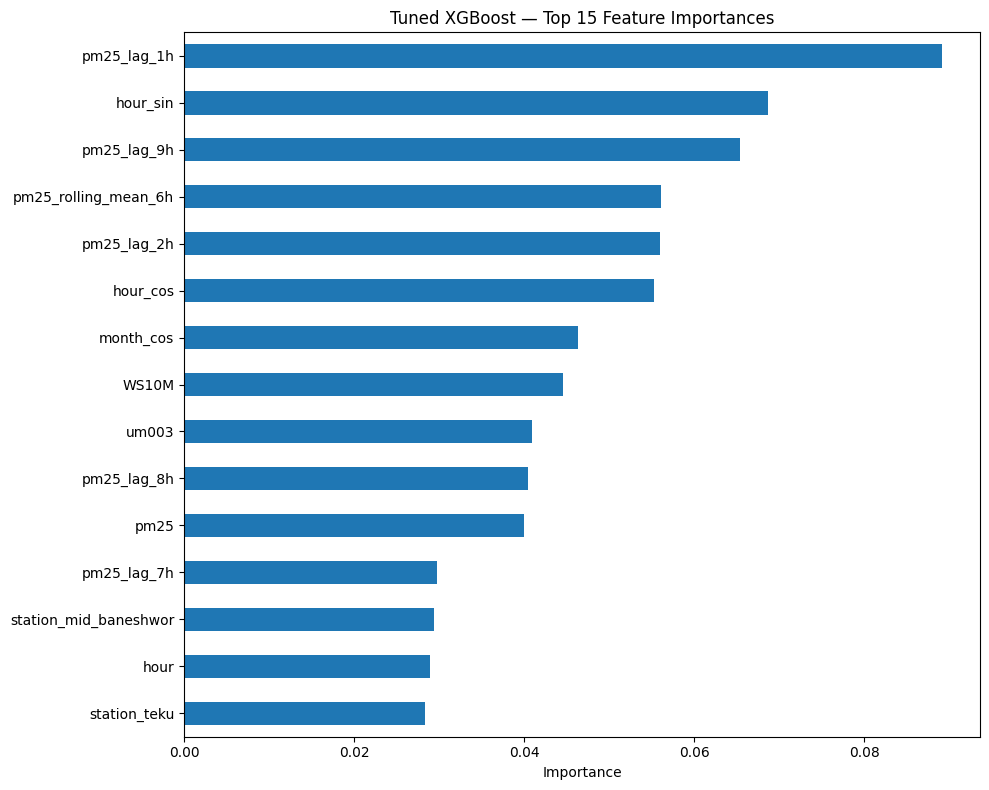

pm25_lag_1h              0.089170
hour_sin                 0.068677
pm25_lag_9h              0.065373
pm25_rolling_mean_6h     0.056144
pm25_lag_2h              0.055945
hour_cos                 0.055236
month_cos                0.046303
WS10M                    0.044569
um003                    0.040884
pm25_lag_8h              0.040499
pm25                     0.040015
pm25_lag_7h              0.029747
station_mid_baneshwor    0.029443
hour                     0.028959
station_teku             0.028374
dtype: float32


In [8]:
final_tuned_model = xgb.XGBRegressor(random_state=42, n_jobs=-1, **best_params)
final_tuned_model.fit(X, y_delta_valid)

importances_tuned = pd.Series(final_tuned_model.feature_importances_, index=feature_columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances_tuned.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Tuned XGBoost — Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances_tuned.head(15))

## 8. Save the tuned model and results

In [9]:
import os
import joblib
import json

os.makedirs("../models", exist_ok=True)

joblib.dump(final_tuned_model, "../models/xgboost_tuned_final.pkl")

tuning_summary = {
    "model": "XGBoost (tuned, delta target)",
    "validation": "TimeSeriesSplit (5 folds), RandomizedSearchCV (n_iter=50)",
    "best_params": best_params,
    "tuned_avg_rmse": final_comparison["rmse_tuned"].mean(),
    "tuned_avg_r2": final_comparison["r2_tuned"].mean(),
    "untuned_avg_rmse": final_comparison["rmse_untuned"].mean(),
    "untuned_avg_r2": final_comparison["r2_untuned"].mean(),
    "persistence_avg_rmse": final_comparison["rmse_persist"].mean(),
    "persistence_avg_r2": final_comparison["r2_persist"].mean(),
}

with open("../models/tuning_results.json", "w") as f:
    json.dump(tuning_summary, f, indent=2, default=str)

print("Saved tuned model to ../models/xgboost_tuned_final.pkl")
print("Saved results to ../models/tuning_results.json")
print(tuning_summary)

Saved tuned model to ../models/xgboost_tuned_final.pkl
Saved results to ../models/tuning_results.json
{'model': 'XGBoost (tuned, delta target)', 'validation': 'TimeSeriesSplit (5 folds), RandomizedSearchCV (n_iter=50)', 'best_params': {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6}, 'tuned_avg_rmse': np.float64(12.874689916425178), 'tuned_avg_r2': np.float64(0.7802821916360692), 'untuned_avg_rmse': np.float64(15.443761553491566), 'untuned_avg_r2': np.float64(0.7198817371971076), 'persistence_avg_rmse': np.float64(14.519869256712715), 'persistence_avg_r2': np.float64(0.7249966435965041)}
